In [ ]:
#| default_exp dtw_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Dynamic Time Warping
> Dynamic Time Warping (DTW) is a method for aligning two time series by allowing non-linear stretching or compression along their temporal axes. 

> Instead of comparing the signals point-by-point, DTW finds an optimal warping path that brings similar patterns into alignment, even when they occur at different speeds or with local temporal distortions. The amount of warping required - measured with respect to a chosen distance metrics - serves as a quantitative measure of dissimilarity between the two time series. This makes DTW particularly useful for comparing signals whose shapes are similar but not temporally synchronized.

In [ ]:
#| eval: false
from fhemb.utils.cutils import depict_DTW, calc_dtw_accuracy, prepare_data, plot_dm_heatmap, plot_dm_projection, svd_dmatrix, depict_accuracy

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
2026-04-24 17:15:50.782804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.s

In [ ]:
#| eval: false
from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

## DTW Alignment 
> is based on distance metrics 

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

::: {.callout-note title="Distance metrics for DTW — What they measure"}
DTW can operate with different point‑wise distance metrics, each defining how local differences between two time‑series samples are evaluated. Choosing a metric determines what "local similarity" means inside DTW, allowing the clustering to emphasize amplitude, shape, correlation, or categorical differences depending on the application.
:::


::: {.callout-note title="Choosing a Distance Metric for DTW"}
Different metrics emphasize different aspects of local similarity inside DTW:

- **euclidean** / **sqeuclidean** - best when absolute amplitude differences matter
- **cityblock** / **minkowski** - robust to outliers; good for piecewise‑linear or sparse changes
- **cosine** / **correlation** - focus on shape rather than magnitude; useful when scaling varies
- **chebyshev** - highlights the single largest deviation; good for threshold‑type signals
- **braycurtis** / **canberra** - emphasize relative changes; useful when values vary across orders of magnitude
- **hamming** / **jaccard** - for categorical or binary time series
- **mahalanobis** - accounts for covariance structure when dimensions are correlated

Selecting a metric determines whether DTW prioritizes amplitude, shape, relative variation, or categorical differences, allowing the clustering to match the structure of your data.
:::

### DTW alignment between two time series

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2

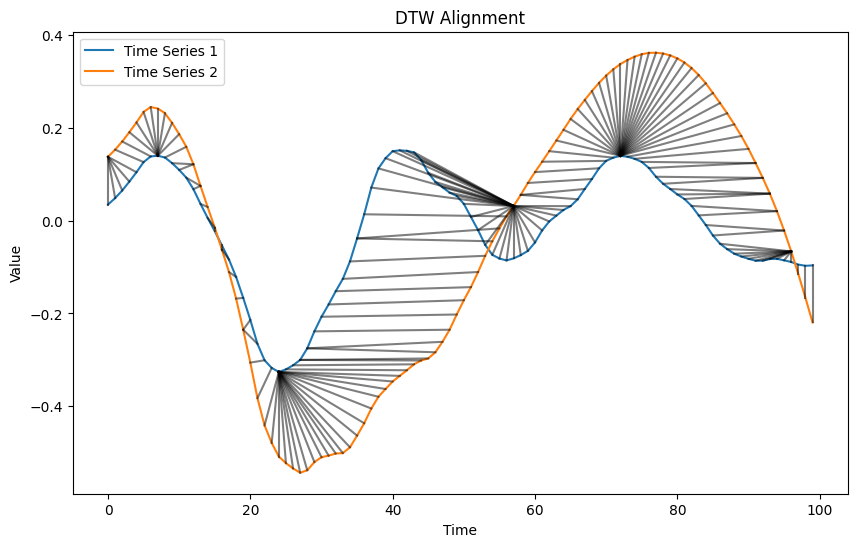

In [ ]:
#| eval: false

depict_DTW(
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj50'][:100], 
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj51'][:100],
    dist=euclidean
)

::: {.callout-note title="DTW alignment of embeddings - What it shows"}
DTW alignment reveals similarity even if events occur a bit earlier or later across synchronized time series.
:::

### DTW alignment between multiple time series
> A non‑clustered distance‑matrix heatmap shows the raw pairwise DTW distances between synchronized time series, in their original ordering.

In [ ]:
#| eval: false

from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('pc0', 'pc1

 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [00:23<00:00, 87.98it/s]


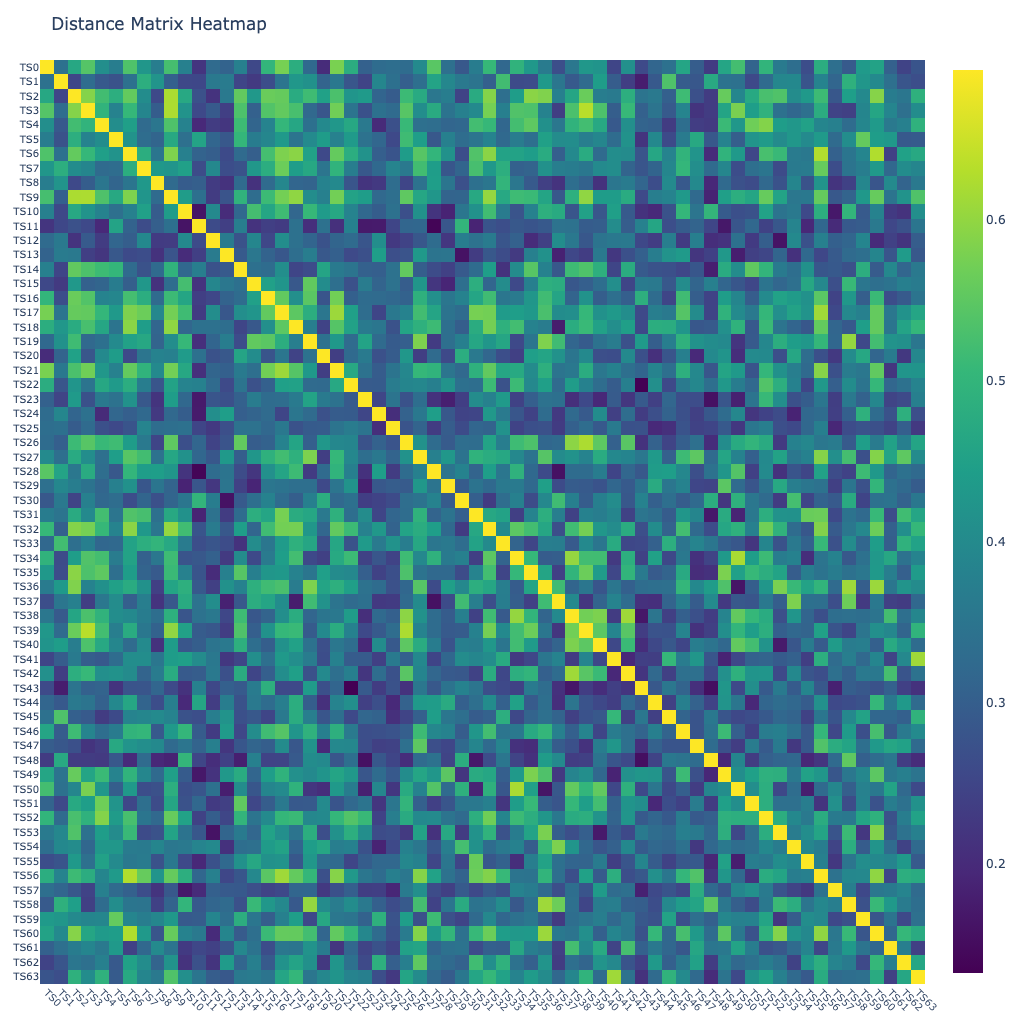

In [ ]:
#| eval: false

plot_dm_heatmap(
    Xdm,                       # data matrix (64 x timesteps) 
    alignment_type='dcor',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # distance metric function used inside fastdtw
    radius=10,                 # refinement window size in fastdtw
    normalize='log',           # normalization method for distance matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
) 

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [06:39<00:00,  5.21it/s]


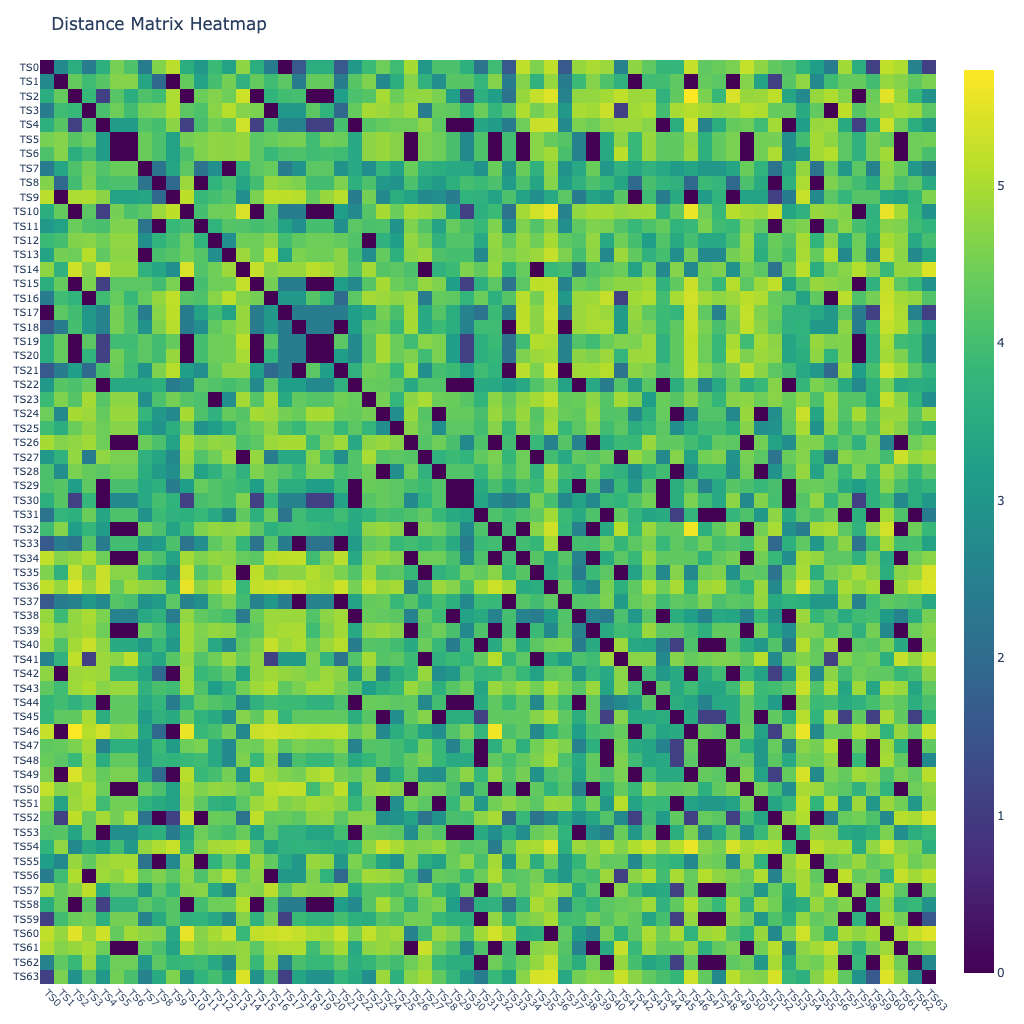

In [ ]:
#| eval: false

plot_dm_heatmap(
    Xdm,                       # data matrix (64 x timesteps) 
    alignment_type='fastdtw',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # distance metric function used inside fastdtw
    radius=10,                 # refinement window size in fastdtw
    normalize='log',           # normalization method for distance matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
)  

::: {.callout-note title="Non‑clustered heatmap diagnostics (Synchronized time series)"}
It helps assess whether the dataset contains meaningful similarity structure before clustering:

- **Uniform appearance** (no visible structure): All time series behave similarly or differences are weak; clustering may not reveal strong groups.
- **Clear stripes** (horizontal or vertical): A specific time series is consistently different from all others — an outlier or atypical subject/channel.
- **Gradients or smooth transitions along the diagonal**: The ordering of the time series reflects a systematic progression (e.g., subjects sorted by condition, intensity).
- **Patchy or noisy texture**: Indicates heterogeneous data quality or inconsistent preprocessing across time series.
- **Large global brightness**: Distances are high overall — time series differ strongly; normalization or scaling may need adjustment.
- **Symmetry check**: The matrix must be symmetric; deviations indicate metric or implementation issues.

This view reveals whether synchronized time series naturally separate into similarity groups, contain outliers, or require preprocessing adjustments before clustering.
:::

::: {.callout-caution title="Diagonal values"}
When the radius is very small (e.g., $\ll 10$), FastDTW restricts the warping window too aggressively. This can force suboptimal alignments, causing unusually large diagonal values in the local cost matrix. These spikes are an artefact of the FastDTW approximation rather than properties of the underlying data.
:::

::: {.callout-important title="Landmark embedding"}
The DTW distance matrix is computed over embedded time series (*primary embedding*). A row of this matrix defines a *landmark embedding*: the vector of DTW dissimilarities from a given embedded time series to all other embedded time series.
Thus, the landmark embedding is a second‑order embedding determined jointly by the primary embedding and by the DTW configuration (`alignment_type`, `dist`, `radius`, `normalize`).
:::

### DTW alignment geometry

#### Distance matrix projection using a dimensionality reduction method
> provides a geometric view of how the synchronized time series relate to each other

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [00:39<00:00, 52.15it/s]
 [WARNING] cutils.plot_dm_projection: PCA assumes a feature matrix, not a distance matrix. Consider using MDS or TSNE for distance-based projections.


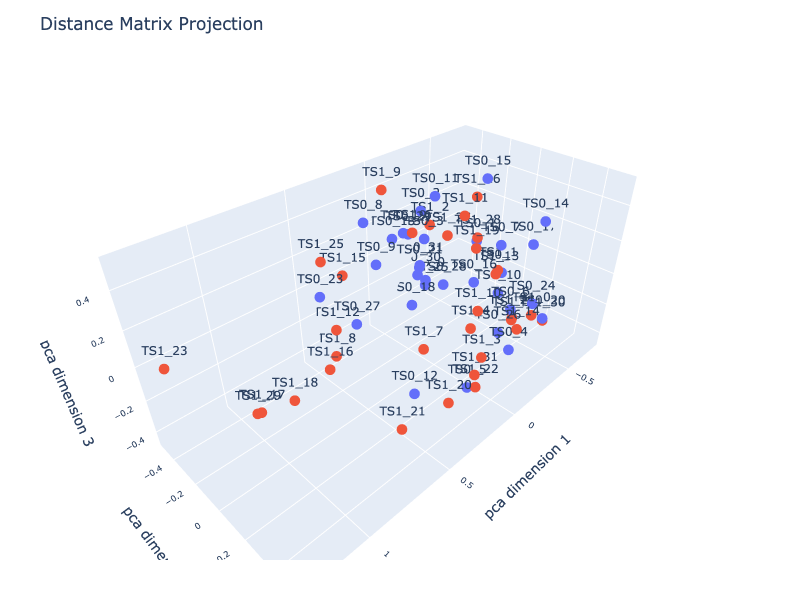

In [ ]:
#| eval: false

plot_dm_projection(
    Xdm[:32], Xdm[32:],         # data matrices for two groups (32 x 64)
    alignment_type='fastdtw',   # alignment method for distance matrix computation           
    dist=cosine,                # distance metric function used inside fastdtw     
    projection='pca',           # projection method for dimensionality reduction ('pca', 'tsne', 'mds') 
    transformation='minmax',    # to transform distances into similarities for PCA
    normalize='log',            # normalization method for distance matrix
    n_jobs=8,                   # number of jobs for parallelization
    dimensions=3,               # number of dimensions of the projection
) 

::: {.callout-note title="Distance-matrix projection diagnostics"}
Look for: 

- **Compact groups** → evidence of cluster structure in the underlying time series
- **Overlapping or diffuse clouds** → weak or ambiguous cluster boundaries
- **Isolated points** → outlier time series with atypical temporal behavior
- **Arcs, curves, or gradients** → continuous progression rather than discrete clusters
- **Changes across preprocessing steps** → reveals whether normalization or filtering improves separability
- **Metric comparison** → different distance metrics produce different geometries; projection shows how strongly
- **A sanity check**: it shows whether the DTW geometry contains meaningful structure before applying any clustering algorithm.
:::

#### Intrinsic dimensionality of a distance matrix via singular value decomposition (SVD)

##### Calculate singular-value spectrum

In [ ]:
#| eval: false

U, S, Vt = svd_dmatrix(       # returns U, S, Vt matrices from SVD of the distance matrix
    Xdm,                      # data matrix (64 x 64)
    alignment_type='fastdtw', # alignment method for distance matrix computation
    dist=cosine,              # distance metric function used inside fastdtw
    radius=2,                 # refinement window size in fastdtw
    transformation='minmax',  # to transform distances into similarities for SVD
    normalize='log',          # normalization method for distance matrix
    n_jobs=8                  # number of jobs for parallelization
)

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [01:02<00:00, 33.04it/s]


::: {.callout-note collapse="false" title="svd_matrix"}
`svd_matrix(X, alignment_type, gamma, transformation, normalize, n_jobs)`  
Computes a **low‑rank decomposition** of a distance‑based similarity matrix using **Singular Value Decomposition (SVD)**.  
This function helps analyze the structure of the similarity geometry and estimate the **intrinsic dimensionality** of the dataset.

**Pipeline**
1. Compute pairwise distances using `alignment_type` (e.g., `fastdtw`).  
2. Convert distances into similarities using `transformation` (e.g., `gauss`, `invert`, `minmax`).  
3. Optionally normalize time series using `normalize`.  
4. Apply SVD to the resulting similarity matrix $\qquad K = U \Sigma V^\top$

**Returns**
- `U` — left singular vectors  
- `S` — singular values  
- `Vt` — right singular vectors  

**Interpretation**
- Singular values `S` quantify how much structure each latent dimension explains.  
- Their decay provides a practical estimate of the **intrinsic dimension** of the similarity space:  
  - sharp drop → low intrinsic dimension  
  - gradual decay → diffuse or noisy structure  
- Conceptually similar to PCA, but applied directly to the **similarity matrix** rather than centered feature data.

**Use cases**
- Inspecting geometric structure before embedding  
- Choosing the number of PCA/MDS components  
- Detecting noise vs. signal in distance‑based representations  
- Low‑rank smoothing or compression of similarity matrices
:::


##### Visualize the singular-value spectrum
>The vector S contains the singular values returned by the SVD. By convention, these values are sorted in descending order, so the first one corresponds to the dominant singular value and subsequent entries decrease monotonically.

In [ ]:
#| eval: false
import matplotlib.pyplot as plt

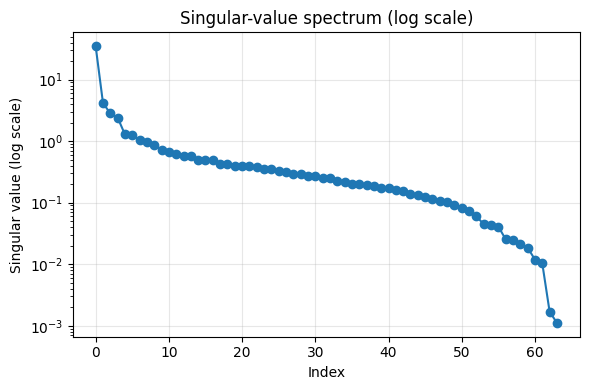

In [ ]:
#| eval: false

plt.figure(figsize=(6, 4))
plt.semilogy(S, marker='o', linewidth=1.5)
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular-value spectrum (log scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

::: {.callout-note title="Intrinsic Dimensionality"}
The singular-value spectrum exhibits a sharp decay after the first four components. This indicates that the matrix is well-approximated by a rank‑4 model, and that the intrinsic dimensionality of the similarity structure is approximately four. Components beyond the fourth lie near the noise floor and contribute minimally to the geometry of the space.
:::

## Classification Accuracy
> of a binary classification problem. A class contains landmark embeddings (rows in a DTW distance matrix) of time series that are synchronized, i.e., belong to the same segment the underlying `Datasource` object.

::: {.callout-note title="Classification accuracy"}
Accuracy quantifies how well a binary classifier distinguishes between two classes of synchronized time‑series embeddings. Each class contains *landmark embeddings* of time series that originate from the same segment of the underlying `Datasource` object. High accuracy indicates that the embeddings preserve class‑specific temporal structure strongly enough for a simple classifier to separate the two groups.
:::

::: {.callout-note title="Landmark embeddings"}
Landmark embeddings arise from a two‑stage process:

1. Primary embeddings (`features`) are aligned by `alignment_type`/`dtw_type` DTW wrt. a distance metrics `dist`/`dtw_filters`.
2. The resulting alignment defines the geometric mapping used to construct the landmark embeddings.
:::

#### The primary embedding `features`

In [ ]:
#| eval: false

emb_prj_decomp_rec1.features

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']


{'percentiles_ts': ('p20', 'p80'),
 'binheights_ts': ('bh1', 'bh2', 'bh3'),
 'pcomponents_ts': ('pc0', 'pc1', 'pc2'),
 'features_ts': ('skew', 'kurtosis')}

### Calculate and store

#### Soft DTW
> uses the squared Euclidean distance as a similarity metric when computing the distance matrix

In [ ]:
#| eval: false

dirname_soft = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_soft_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():   # iterate over all features of the EmbeddingCollection object 
    for feature in features:                                       # 
        print(f"Embedding: {embedding}, Feature: {feature}")
        X, y = prepare_data(                                                        # prepare the matrix X and label vector y for the two groups
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T,   # first 500 samples for group 0
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T    # last 500 samples for group 1
        )
        print(f"Shape: {X.shape}")    # matrix (n_samples x n_dataframes)
        filename=calc_dtw_accuracy(   # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename 
            X[y==0],                  # group 0
            X[y==1],                  # group 1
            dirname=dirname_soft,     # directory in which the results Excel file will be stored
            dtw_type='soft_dtw',      # alignment method for distance matrix computation
            normalize='minmax',       # normalization method for distance matrix
            feature=feature,          # feature name for labeling the results
            random_states=10          # number of random states for train/test splits in classification    
        )
        print(f"Saved results to: {filename}")

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_

Embedding: percentiles_ts, Feature: p20
Shape: (64, 500)


Computing DTW distances:   0%|          | 0/990 [00:00<?, ?it/s]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlo

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_p20.xlsx
Embedding: percentiles_ts, Feature: p80
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:04<00:00, 214.79it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:03<00:00, 243.40it/s]
 [INFO] cutils.calc_accuracies: Accuracy of KNN with nan_euclidean metric: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of KNN with cosine metric: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of KNN with euclidean metric: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of KNN with l1 metric: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of KNN with minkowski metric: 0.50
 [WARNING] cutils.calc_accuracies: Error with metric precomputed: Negative values in data passed to X.
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid

...

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_pc2.xlsx
Embedding: features_ts, Feature: skew
Shape: (64, 500)


 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 990/990 [00:04<00:00, 246.11it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:03<00:00, 287.87it/s]
 [INFO] cutils.calc_accuracies: Accuracy of KNN with nan_euclidean metric: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of KNN with cosine metric: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of KNN with euclidean 

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_skew.xlsx
Embedding: features_ts, Feature: kurtosis
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:03<00:00, 276.40it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:03<00:00, 289.44it/s]
 [INFO] cutils.calc_accuracies: Accuracy of KNN with nan_euclidean metric: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of KNN with cosine metric: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of KNN with euclidean metric: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of KNN with l1 metric: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of KNN with minkowski metric: 0.65
 [WARNING] cutils.calc_accuracies: Error with metric precomputed: Negative values in data passed to X.
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_kurtosis.xlsx


#### FastDTW
> uses various distance metrics as a similarity metric when computing the distance matrix 

In [ ]:
dirname_fast = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_fast_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():    #                 
    for feature in features:                                        #
        if feature in ['pc1', 'pc2']:                               # iterate over this list of features of the EmbeddingCollection object 
            print(f"Embedding: {embedding}, Feature: {feature}")
            X, y = prepare_data(                                                      # prepare the matrix X and label vector y for the two groups
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T, # first 500 samples for group 0
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T  # last 500 samples for group 1
            )
            print(f"Shape: {X.shape}")         # matrix (n_samples x n_dataframes)
            filename=calc_dtw_accuracy(        # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename  
                X[y==0],                       # group 0
                X[y==1],                       # group 1
                dirname=dirname_fast,          # directory in which the results Excel file will be stored
                dtw_type='fastdtw',            # alignment method for distance matrix computation
                normalize='minmax',            # normalization method for distance matrix
                radius=1,                      # refinement window size in fastdtw (only used for fastdtw)
                feature=feature,               # feature name for labeling the results
                random_states=10               # number of random states for train/test splits in classification
            )
            print(f"Saved results to: {filename}")
        else:
            print(f"Skipping Embedding: {embedding}, Feature: {feature} for fastdtw")    

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_

Skipping Embedding: percentiles_ts, Feature: p20 for fastdtw
Skipping Embedding: percentiles_ts, Feature: p80 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh1 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh2 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh3 for fastdtw
Skipping Embedding: pcomponents_ts, Feature: pc0 for fastdtw
Embedding: pcomponents_ts, Feature: pc1
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:26<00:00, 37.31it/s]
 [INFO] cutils.calc_dtw_dmatrix: Using euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:24<00:00, 36.36it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.35
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.50
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [WARNING] py.warni

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc1.xlsx
Embedding: pcomponents_ts, Feature: pc2
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:37<00:00, 26.48it/s]
 [INFO] cutils.calc_dtw_dmatrix: Using euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:34<00:00, 25.39it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.45
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [WARNING] py.warni

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc2.xlsx
Skipping Embedding: features_ts, Feature: skew for fastdtw
Skipping Embedding: features_ts, Feature: kurtosis for fastdtw


### Retrieve and visualize
> Accuracy of multiple classifiers on various landmark embeddings

In [ ]:
#| eval: false

COLUMNS_FILTER=[
        'knn_precomputed', 
        'knn_cosine', 
        'knn_l1', 
        'knn_euclidean', 
        'knn_minkowski', 
        'rotf', 
        'randf', 
        'svm_precomputed', 
        'svm_rbf', 
        'svm_poly', 
        'svm_linear'
    ]

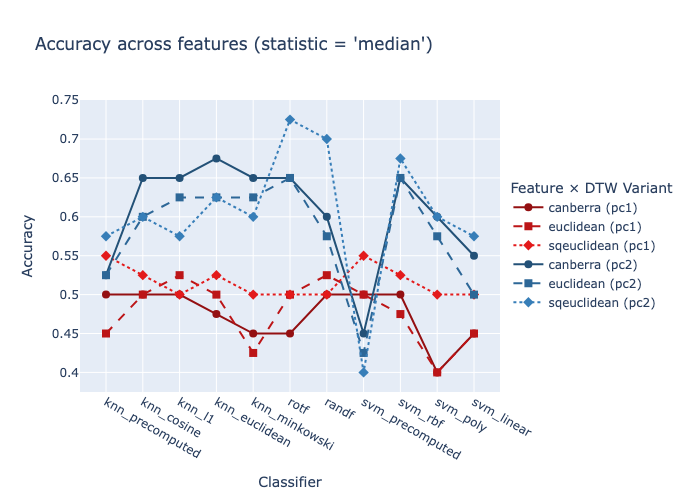

In [ ]:
#| eval: false

depict_accuracy(                         # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` and  `dtw_filter` 
    dirname_fast,                        # directory from which the results are loaded
    features=['pc2', 'pc1'],             # the features of the primary embeddings for which the accuracy will be visualized
    statistics='median',                 # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    dtw_filter=[                         # list of DTW alignment distance metrics to include in the visualization
        'euclidean', 
        'sqeuclidean', 
        'canberra'
    ],          
    columns_filter=COLUMNS_FILTER,       # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                         # for debugging
);

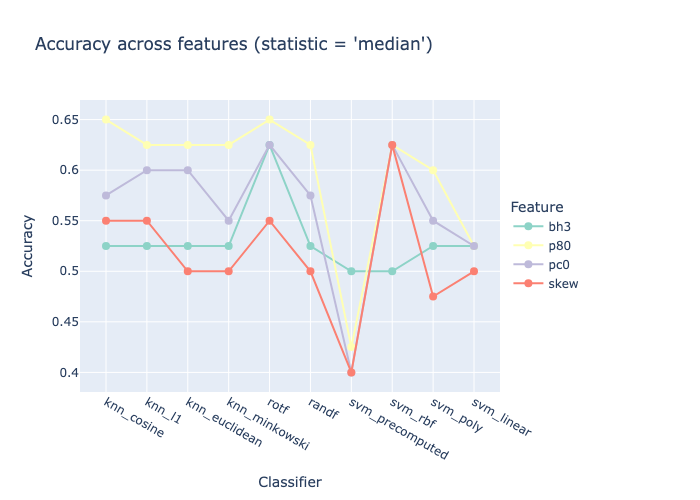

In [ ]:
#| eval: false

depict_accuracy(                             # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` 
    dirname_soft,                            # directory from which the results are loaded
    features=['p80', 'bh3', 'pc0', 'skew'],  # the features of the primary embeddings for which the accuracy will be visualized      
    statistics='median',                     # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    columns_filter=COLUMNS_FILTER,           # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                             # for debugging
);